In [1]:
#MIWAF PHASE 2 - MACHINE LEARNING
#Notebook 1: Feature Engineering
#Author: Mbugua Hellen Njeri | Reg no: 24/05982
#Description: Preparing Maji Ndogo data for ML Models

In [2]:
#Step 1 Import all the libraries needed
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import pymysql
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully')

All libraries imported successfully


In [3]:
connection = pymysql.connect(
    host     = "localhost",
    user     = "root",
    password = "H@4115m4",
    database = "majindogo"
)
print("✅ Connected to majindogo successfully!")

✅ Connected to majindogo successfully!


In [4]:
water_source = pd.read_sql("Select * from water_source", connection)
location = pd.read_sql("Select * from location", connection)
visits = pd.read_sql("Select * from visits", connection)
newtable_1 = pd.read_sql("Select * from newtable_1",connection)
crime = pd.read_sql("Select * from water_source_related_crime", connection)
print("All tables loaded!")
print(f"water_source : {water_source.shape}")
print(f" location : {location.shape}")
print(f" visits : {visits.shape}")
print(f" well_pollution : {newtable_1.shape}")
print(f" crime : {crime.shape}")

All tables loaded!
water_source : (39650, 3)
 location : (39650, 5)
 visits : (60146, 7)
 well_pollution : (17383, 6)
 crime : (77226, 5)


In [5]:
#Quick look at the tables 
print("=" * 50)
print("Water Source table = First 3 rows:")
print(water_source.head(3))

print("\n" + "=" *50)
print("Location Table - First 3 rows:")
print(location.head(3))

print("\n" + "=" * 50)
print("Well pollution table - First 3 rows:")
print(newtable_1.head(3))

Water Source table = First 3 rows:
      source_id type_of_water_source  number_of_people_served
0  AkHa00000224          tap_in_home                      956
1  AkHa00001224   tap_in_home_broken                      930
2  AkHa00002224   tap_in_home_broken                      486

Location Table - First 3 rows:
  location_id              address town_name location_type province_name
0   AkHa00000   2 Addis Ababa Road    Harare         Urban        Akatsi
1   AkHa00001  10 Addis Ababa Road    Harare         Urban        Akatsi
2   AkHa00002   9 Addis Ababa Road    Harare         Urban        Akatsi

Well pollution table - First 3 rows:
      source_id            date  \
0  KiRu28935224   1/4/2021 9:17   
1  AkLu01628224   1/4/2021 9:53   
2  HaZa21742224  1/4/2021 10:37   

                                         description  pollutant_ppm  \
0                          Bacteria: Giardia Lamblia          0.000   
1                                  Bacteria: E. coli          0.000   
2

In [6]:
#Build a Master Dataframe
#Join the visits with water_source tables
master_df = visits.merge(
    water_source,
    on = 'source_id',
    how = 'left'
)
#Add location details
master_df = master_df.merge(
    location,
    on = 'location_id',
    how = 'left'
)
#Remove negative queue times
master_df = master_df[master_df['time_in_queue'] >=0]
print("master_df built successfully!")
print(f" shape : {master_df.shape}")
print(f" columns : {list(master_df.columns)}")

master_df built successfully!
 shape : (60146, 13)
 columns : ['record_id', 'location_id', 'source_id', 'time_of_record', 'assigned_employee_id', 'time_in_queue', 'visit_count', 'type_of_water_source', 'number_of_people_served', 'address', 'town_name', 'location_type', 'province_name']


In [7]:
# Extract time features from the timestamp
master_df['time_of_record'] = pd.to_datetime(
    master_df['time_of_record']
)

master_df['hour']        = master_df['time_of_record'].dt.hour
master_df['day_of_week'] = master_df['time_of_record'].dt.dayofweek
master_df['month']       = master_df['time_of_record'].dt.month
master_df['is_weekend']  = master_df['day_of_week'].apply(
                               lambda x: 1 if x >= 5 else 0
                           )

print("✅ Time features extracted!")
print(master_df[['time_of_record', 'hour',
                  'day_of_week', 'month',
                  'is_weekend']].head(5))

✅ Time features extracted!
       time_of_record  hour  day_of_week  month  is_weekend
0 2021-01-01 09:10:00     9            4      1           0
1 2021-01-01 09:17:00     9            4      1           0
2 2021-01-01 09:36:00     9            4      1           0
3 2021-01-01 09:53:00     9            4      1           0
4 2021-01-01 10:11:00    10            4      1           0


In [8]:
#Convert Text to Numbers
from sklearn.preprocessing import LabelEncoder
le_source = LabelEncoder()
le_location = LabelEncoder()
le_province = LabelEncoder()

master_df['source_type_encoded'] = le_source.fit_transform(
    master_df['type_of_water_source']
)
master_df['location_type_encoded'] = le_location.fit_transform(
    master_df["location_type"]
)
master_df['province_encoded'] = le_province.fit_transform(
    master_df['province_name']
)
print("Text columns converted to numbers!")
print("\nSource type mapping:")
for original, encoded in zip(
    le_source.classes_,
    range(len(le_source.classes_))
):
    print(f" {original} {encoded}")

print("\nProvince mapping:")
for original, encoded in zip(
    le_province.classes_,
    range(len(le_province.classes_))
):
    print(f" {original} {encoded}")

Text columns converted to numbers!

Source type mapping:
 river 0
 shared_tap 1
 tap_in_home 2
 tap_in_home_broken 3
 well 4

Province mapping:
 Akatsi 0
 Amanzi 1
 Hawassa 2
 Kilimani 3
 Sokoto 4


In [9]:
#Save Encoders
import pickle
import os
os.makedirs('../models', exist_ok=True)
encoders = {
    'le_source' : le_source,
    'le_location' : le_location,
    'le_province' : le_province
    
}
with open('../models/encoders.pkl','wb') as f:
    pickle.dump(encoders, f)
print("Encoders saved to ../models/encoders.pkl")

Encoders saved to ../models/encoders.pkl


In [10]:
# Model 1 Dataset - Contamination Classifier
# Using newtable_1 which has all contamination records

contamination_df = well_pollution_full.merge(
    water_source,
    on  = 'source_id',
    how = 'left'
)

# Create target column
# 1 = Contaminated (Chemical OR Biological)
# 0 = Clean
contamination_df['is_contaminated'] = contamination_df['results'].apply(
    lambda x: 1 if 'Contaminated' in str(x) else 0
)

# Also create a detailed contamination type column
# This will be useful for deeper analysis later
contamination_df['contamination_type'] = contamination_df['results'].apply(
    lambda x: 'Biological' if 'Biological' in str(x)
              else ('Chemical' if 'Chemical' in str(x)
              else 'Clean')
)

# Select features for Model 1
model1_df = contamination_df[[
    'pollutant_ppm',
    'biological',
    'is_contaminated',
    'contamination_type'
]].dropna()

print(" Model 1 dataset ready!")
print(f"   Shape: {model1_df.shape}")
print(f"\nContamination breakdown:")
print(model1_df['is_contaminated'].value_counts())
print(f"\nContamination type breakdown:")
print(model1_df['contamination_type'].value_counts())
print(f"\nPercentage contaminated: "
      f"{model1_df['is_contaminated'].mean()*100:.1f}%")
print(f"\nFirst 5 rows:")
print(model1_df.head())

NameError: name 'well_pollution_full' is not defined

In [ ]:
#Model 2 Dataset (Queue Time)
model2_df = master_df[[
    'source_type_encoded',
    'location_type_encoded',
    'province_encoded',
    'number_of_people_served',
    'hour',
    'day_of_week',
    'is_weekend',
    'time_in_queue'
]].dropna()

print("Model 2 dataset ready!")
print(f"   Shape: {model2_df.shape}")
print(f"\nQueue time statistics:")
print(model2_df['time_in_queue'].describe())

Model 2 dataset ready!
   Shape: (60146, 8)

Queue time statistics:
count    60146.000000
mean        60.745469
std         92.207404
min          0.000000
25%          0.000000
50%          0.000000
75%        102.000000
max        539.000000
Name: time_in_queue, dtype: float64


In [ ]:
#Model 3 Dataset(Crime Risk)
crime['time_of_incident'] = pd.to_datetime(
    crime['time_of_incident'], errors='coerce'
)
crime['incident_hour'] = crime['time_of_incident'].dt.hour
crime['incident_day'] = crime['time_of_incident'].dt.day_of_week
crime['gender_encoded'] = crime['victim_gender'].map(
    {'F':0, 'M': 1, 'C':2}
)
def assign_risk(crime_type):
    high = ['severe_assault', 'murder', 'sexual_assault']
    medium = ['harassment', 'theft']
    if crime_type in high:
        return 2 
    elif crime_type in medium:
        return 1
    else:
        return 0
    
crime['risk_level'] = crime['crime_type'].apply(assign_risk)

model3_df = crime[[
    'incident_hour',
    'incident_day',
    'gender_encoded',
    'risk_level'
]].dropna()

print("Model 3 dataset ready!")
print(f" Shape: {model3_df.shape}")
print(f"\nRisk level breakdown:")
risk_map = {0: 'Low', 1: 'Medium', 2: 'High'}
print(model3_df['risk_level'].map(risk_map).value_counts())

Model 3 dataset ready!
 Shape: (77226, 4)

Risk level breakdown:
risk_level
Medium    37535
High      24534
Low       15157
Name: count, dtype: int64


In [ ]:
# Save all 3 datasets

import os

# Use the actual path of your notebook folder
notebook_dir = os.getcwd()
outputs_dir  = os.path.join(notebook_dir, 'outputs')

# Create outputs folder in the SAME folder as your notebook
os.makedirs(outputs_dir, exist_ok=True)

# Save all 3 datasets
model1_df.to_csv(
    os.path.join(outputs_dir, 'model1_contamination_data.csv'),
    index=False
)
model2_df.to_csv(
    os.path.join(outputs_dir, 'model2_queue_data.csv'),
    index=False
)
model3_df.to_csv(
    os.path.join(outputs_dir, 'model3_crime_data.csv'),
    index=False
)

print("All 3 datasets saved!")
print(f"   Saved to: {outputs_dir}")
print(f"   → model1_contamination_data.csv")
print(f"   → model2_queue_data.csv")
print(f"   → model3_crime_data.csv")

All 3 datasets saved!
   Saved to: c:\Users\njeri\OneDrive\Documents\SCHOOL-BDS\2.3\Final Year Project\notebooks\outputs
   → model1_contamination_data.csv
   → model2_queue_data.csv
   → model3_crime_data.csv


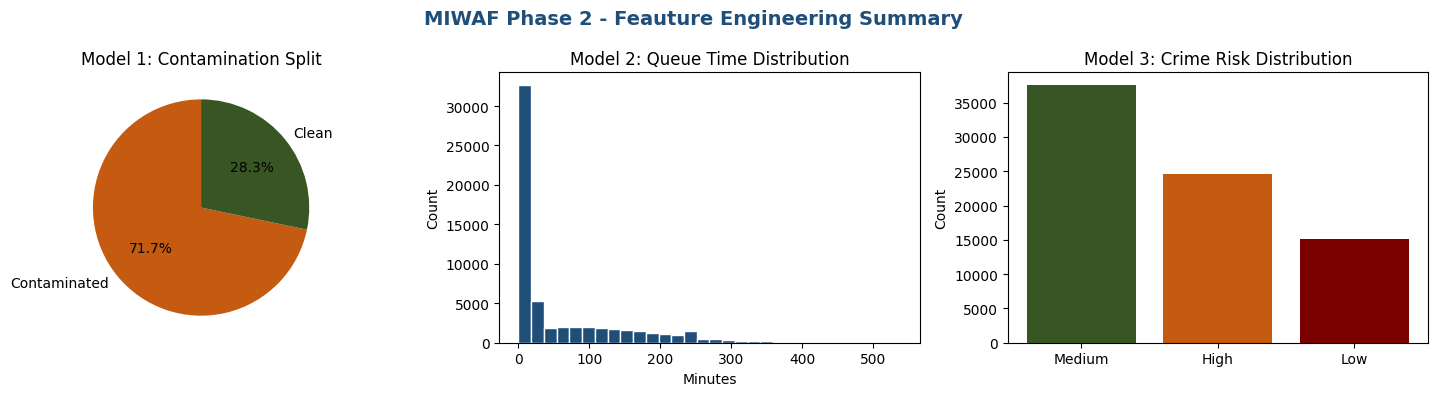

Model 1 dataset : (17383, 4)
Model 2 dataset : (60146, 8)
Model 3 dataset : (77226, 4)


In [ ]:
#Final Summary Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    'MIWAF Phase 2 - Feauture Engineering Summary',
    fontsize=14, fontweight='bold', color='#1F4E79'
)
#Chart 1 Contamination Split
axes[0].pie(
    model1_df['is_contaminated'].value_counts(),
    labels = ['Contaminated', 'Clean'],
    colors = ['#C55A11', '#375623'],
    autopct = '%1.1f%%',
    startangle = 90
)
axes[0].set_title('Model 1: Contamination Split')

#Chart 2 - Queue Time Distribution
axes[1].hist(
    model2_df['time_in_queue'],
    bins = 30,
    color = '#1F4E79',
    edgecolor = 'white'
)
axes[1].set_title('Model 2: Queue Time Distribution')
axes[1].set_xlabel('Minutes')
axes[1].set_ylabel('Count')

#Chart 3 - Crime Risk Distribution
risk_counts = model3_df['risk_level'].map(
    {0:'Low', 1:'Medium', 2:'High'}
).value_counts()
axes[2].bar(
    risk_counts.index,
    risk_counts.values,
    color = ['#375623', '#C55A11', '#7b0000']
)
axes[2].set_title('Model 3: Crime Risk Distribution')
axes[2].set_ylabel('Count')
plt.tight_layout()
plt.savefig(
    os.path.join(outputs_dir, 'feauture_engineering_summary.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("=" * 50)
print(f"Model 1 dataset : {model1_df.shape}")
print(f"Model 2 dataset : {model2_df.shape}")
print(f"Model 3 dataset : {model3_df.shape}")
print("=" * 50)